# Phase 1 - Exploratory Data Analysis (EDA)

Explore the raw Wine Quality dataset before any modeling: structure, distributions,
correlations, target imbalance and red-vs-white differences. Figures are saved to
`reports/figures/` for the written report.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
os.chdir(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_and_combine, FEATURE_COLUMNS

sns.set_theme(style='whitegrid')
os.makedirs('reports/figures', exist_ok=True)

# Load the RAW combined data (wine_type kept as text for readable plots).
df = load_and_combine('data/raw/winequality-red.csv', 'data/raw/winequality-white.csv')
print('Shape:', df.shape)
df.head()

Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 1. Structure and basic statistics

In [2]:
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB

Missing values per column:
fixed acidity           0
volatile 

In [3]:
# Describe the 11 features (transposed for readability).
df[FEATURE_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


wine_type
white    4898
red      1599
Name: count, dtype: int64


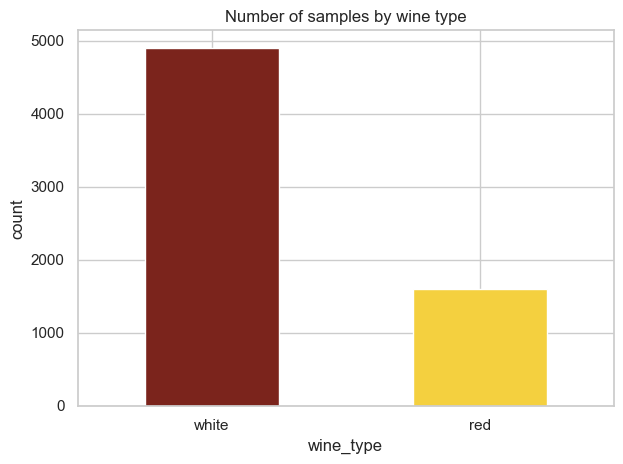

In [4]:
# Counts by wine type.
print(df['wine_type'].value_counts())
df['wine_type'].value_counts().plot(kind='bar', color=['#7b241c', '#f4d03f'])
plt.title('Number of samples by wine type')
plt.ylabel('count'); plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('reports/figures/eda_wine_type_counts.png', dpi=120)
plt.show()

## 2. Distribution of every feature (histograms)

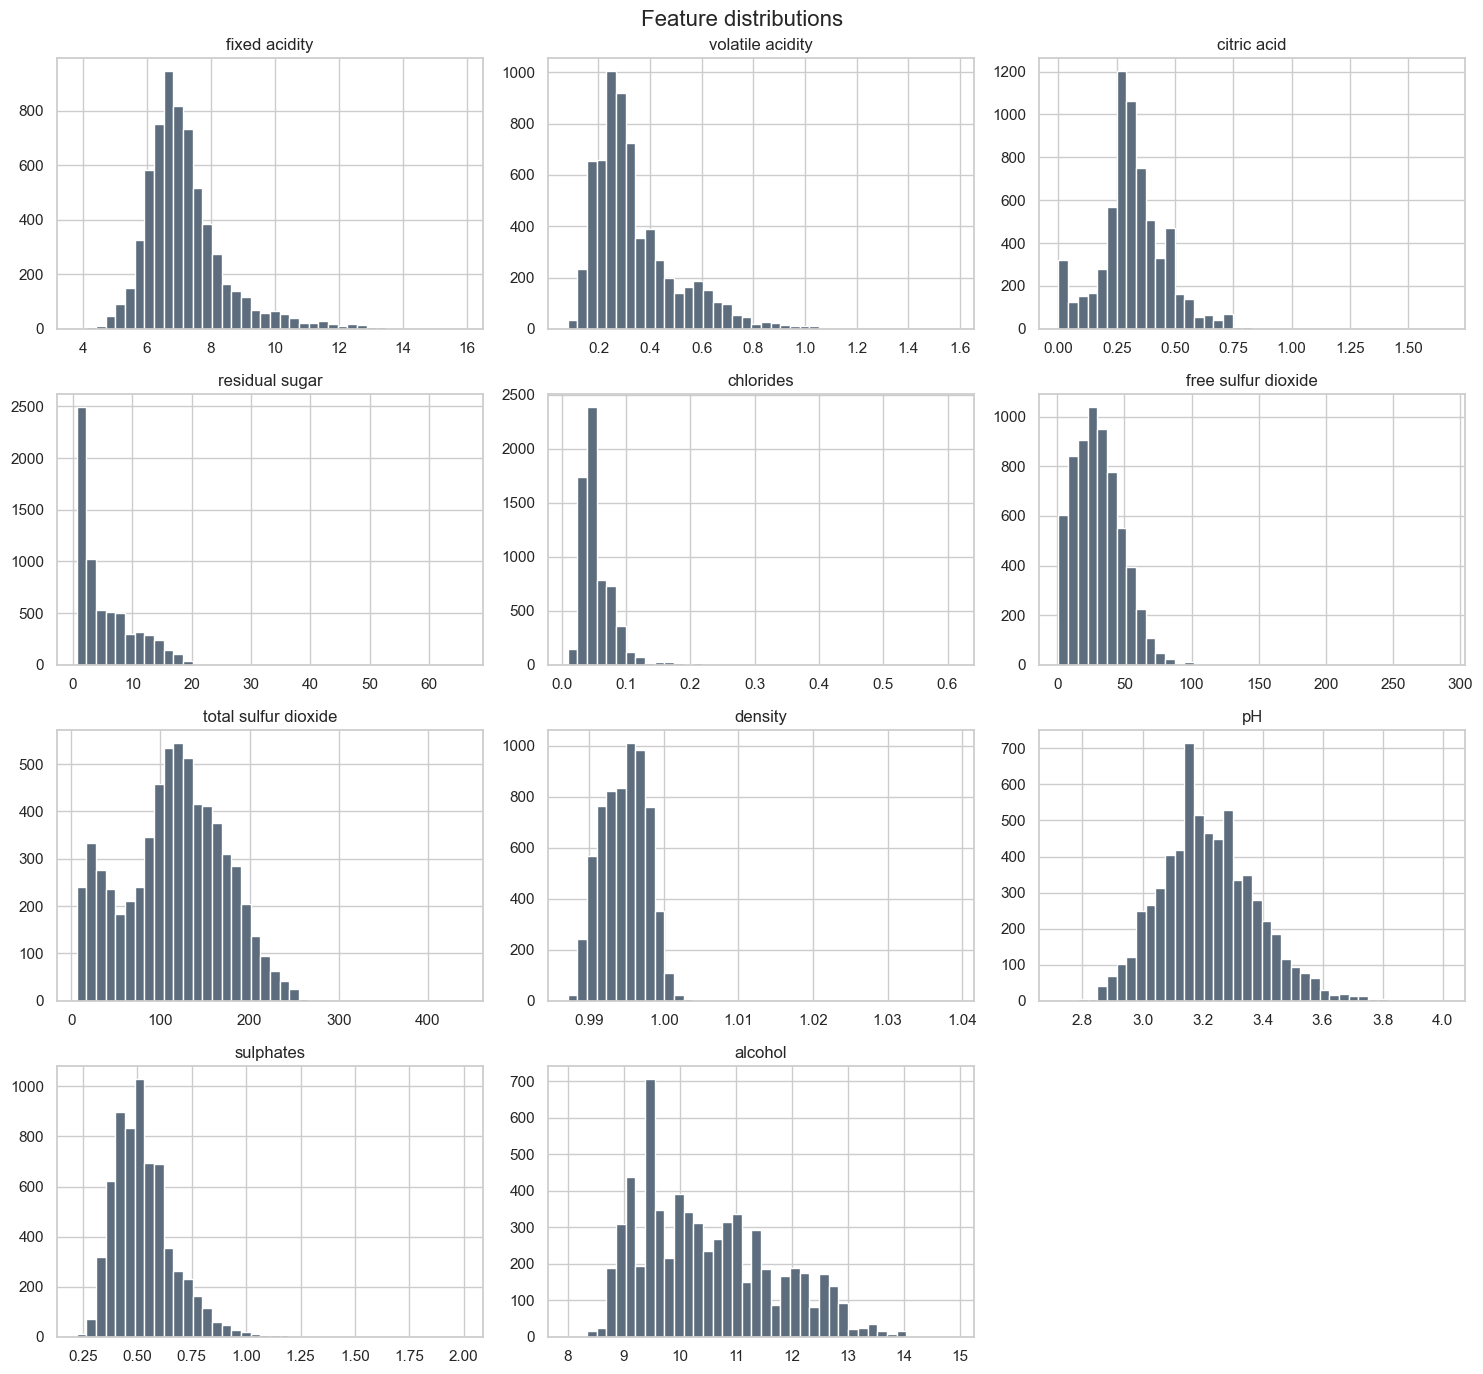

In [5]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
for ax, col in zip(axes.ravel(), FEATURE_COLUMNS):
    ax.hist(df[col], bins=40, color='#5d6d7e', edgecolor='white')
    ax.set_title(col)
# Hide the unused 12th subplot.
axes.ravel()[-1].axis('off')
plt.suptitle('Feature distributions', fontsize=16)
plt.tight_layout()
plt.savefig('reports/figures/eda_histograms.png', dpi=120)
plt.show()

## 3. Correlation matrix

Which features move together? Note the strong `alcohol`-vs-`quality` relationship
and the `density` correlations.

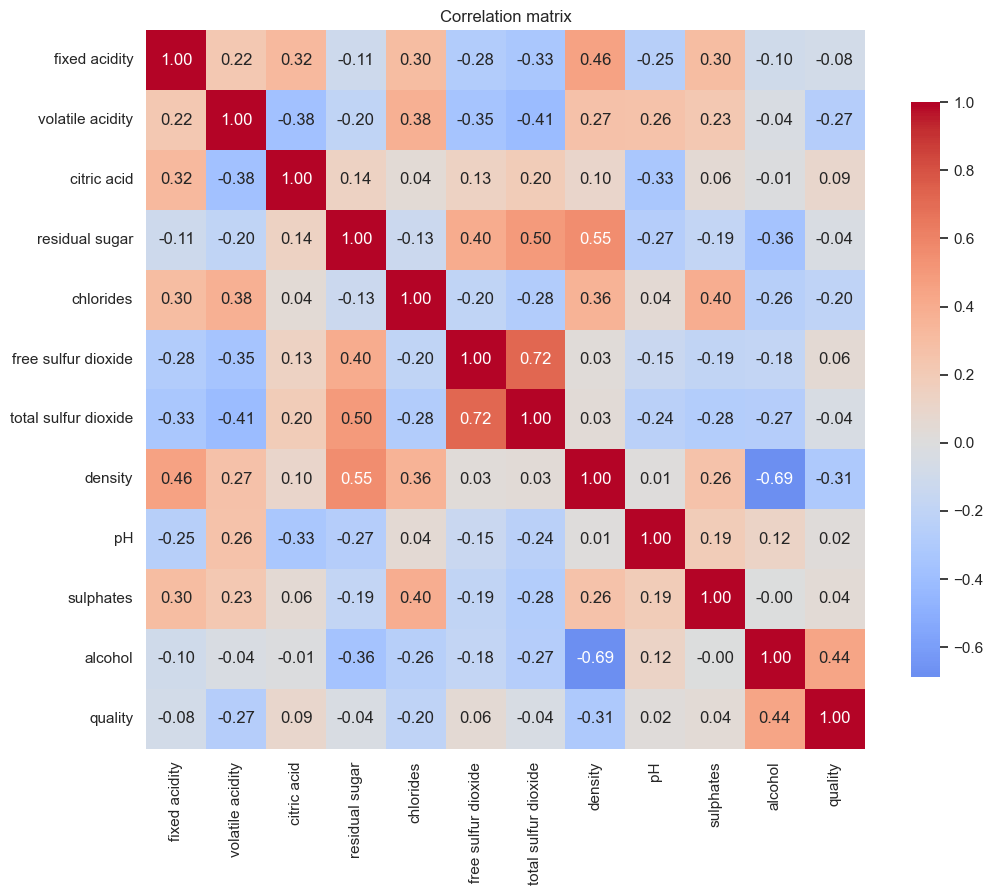

In [6]:
plt.figure(figsize=(11, 9))
corr = df[FEATURE_COLUMNS + ['quality']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('reports/figures/eda_correlation.png', dpi=120)
plt.show()

## 4. Target (`quality`) distribution - the imbalance

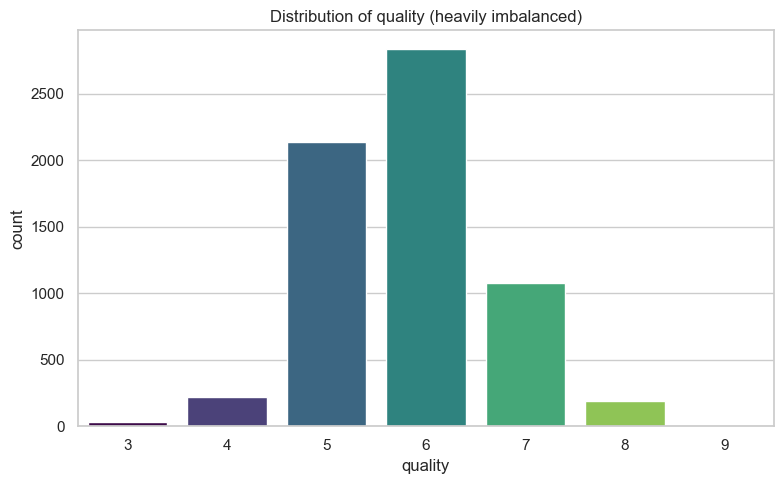

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, hue='quality', palette='viridis', legend=False)
plt.title('Distribution of quality (heavily imbalanced)')
plt.tight_layout()
plt.savefig('reports/figures/eda_quality_distribution.png', dpi=120)
plt.show()
print(df['quality'].value_counts().sort_index())

## 5. Red vs white: structural differences (boxplots)

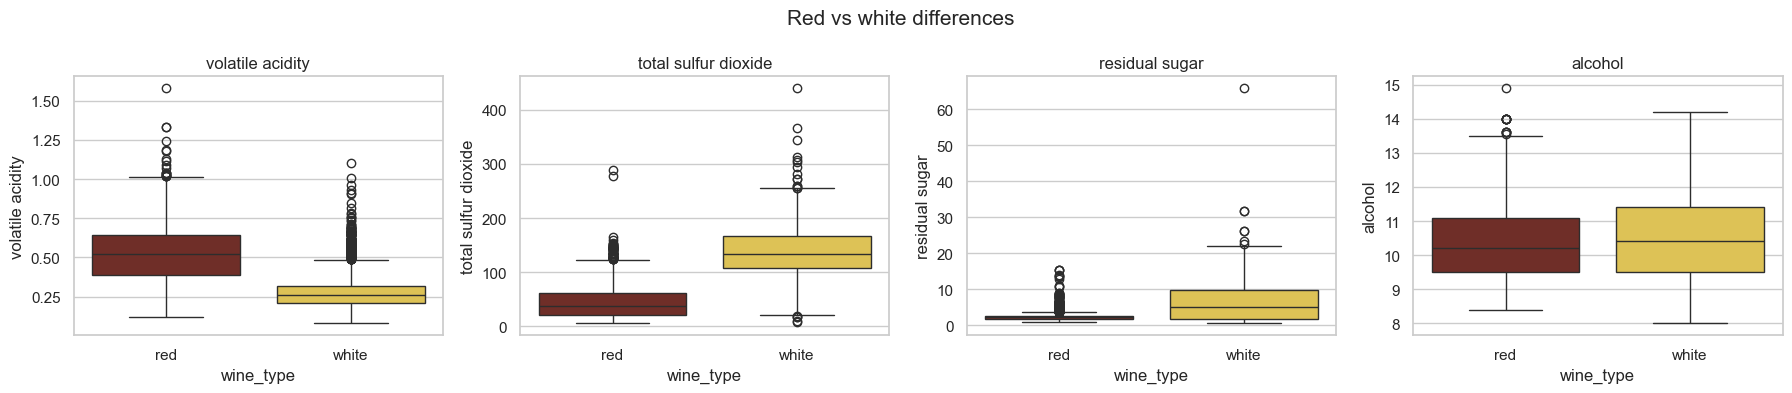

In [8]:
key_feats = ['volatile acidity', 'total sulfur dioxide', 'residual sugar', 'alcohol']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, key_feats):
    sns.boxplot(x='wine_type', y=col, data=df, hue='wine_type',
                palette=['#7b241c', '#f4d03f'], legend=False, ax=ax)
    ax.set_title(col)
plt.suptitle('Red vs white differences', fontsize=15)
plt.tight_layout()
plt.savefig('reports/figures/eda_red_vs_white.png', dpi=120)
plt.show()

## 6. Alcohol vs quality (the strongest relationship)

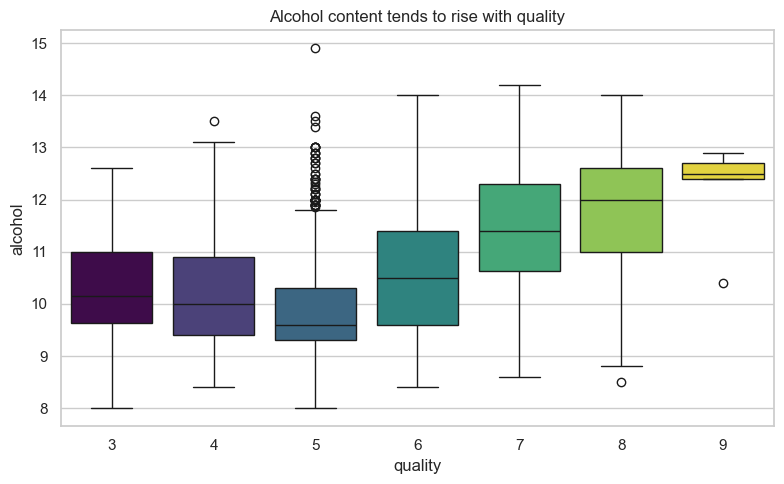

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='quality', y='alcohol', data=df, hue='quality',
            palette='viridis', legend=False)
plt.title('Alcohol content tends to rise with quality')
plt.tight_layout()
plt.savefig('reports/figures/eda_alcohol_vs_quality.png', dpi=120)
plt.show()

## Summary

- 6.497 wines (1.599 red + 4.898 white), 11 numeric features + `quality`.
- No missing values, but ~1.177 duplicate rows -> removed in preprocessing.
- `residual sugar` and `total sulfur dioxide` have strong right-tailed outliers
  -> winsorized in preprocessing.
- `quality` is heavily imbalanced (classes 5-6 dominate).
- `alcohol` shows the strongest positive link with `quality`.
- Red and white wines differ structurally (esp. SO2 and volatile acidity).